# **EVIDENCIA DE EXTRACCIÓN Y ANÁLISIS DE DATOS**
## Leads de Piso 2025 y BCS

En esta evidencia analizo dos bases del socio formador: Leads de Piso 2025, que contiene registros mensuales por asesor, y BCS, de la cual selecciono los objetivos y las ventas reales por modelo de vehículo. El propósito es preparar la información, describir su distribución y examinar relaciones mediante regresión lineal simple.

El análisis de Leads de Piso reúne 244 registros de enero a abril entre 35 asesores, después de separar cuentas administrativas y agrupar un nombre duplicado. En BCS, los seis modelos seleccionados suman 41 ventas reales frente a 44 unidades de objetivo por modelo. La concentración de registros y las diferencias entre metas requieren interpretarse junto con la calidad de captura.

## Bases principales

| Base | Archivo de entrada | Unidad de análisis |
|---|---|---|
| Leads de Piso 2025 | leads_piso_2025_sin_nulos.csv | Asesor con conteos de enero a abril de 2025 |
| BCS | Analisis GAC Full7agosto 2026( BCS).csv | Modelo de vehículo en la sección de ventas |

## Etapas del trabajo

- Extracción y transformación de las dos bases.
- Verificación de nulos y ejemplo complementario de sustitución.
- Detección de valores atípicos y justificación de su conservación.
- Extracción de características y elaboración de gráficas.
- Regresión lineal simple y análisis de correlación.
- Hallazgos, propuestas y conclusión.

## Alcance

Leads de Piso contiene cantidades registradas, no identificadores de clientes únicos ni ventas. BCS no es una serie mensual de 2025: su encabezado incluye la fecha 24 de agosto de 2026. Las bases se analizan por separado porque no cuentan con una clave y un periodo común que justifiquen unirlas.

Citas Digitales se utiliza únicamente como ejemplo complementario de los métodos de nulos y atípicos trabajados en las actividades 2.1 y 3.1. Los resultados principales corresponden a Leads de Piso 2025 y BCS.

# **EXTRACCIÓN Y TRANSFORMACIÓN DE LEADS DE PISO**

## Lectura y normalización

El archivo de entrada contiene 40 filas y cinco columnas: Asesor, ene, feb, mar y abr. Está guardado como una versión sin nulos. Limpio espacios en los encabezados y normalizo el campo Asesor con mayúsculas y un solo espacio entre palabras. Después convierto los cuatro meses a conteos numéricos.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

leads = pd.read_csv("leads_piso_2025_sin_nulos.csv", dtype=str)
leads.columns = leads.columns.str.strip()
leads["Asesor"] = (
    leads["Asesor"].str.replace("\u00a0", " ", regex=False)
    .str.replace(r"\s+", " ", regex=True).str.strip().str.upper()
)
meses = ["ene", "feb", "mar", "abr"]
leads[meses] = leads[meses].apply(pd.to_numeric, errors="raise")

## Separación de cuentas administrativas

Aplico el criterio de separación de cuentas administrativas utilizado en la preparación de ventas de la actividad 5.2. CASA, DEMO VENDEDOR, USUARIO DE BDC Y CASA y SYS_COMPETITION quedan fuera del análisis por asesor. CASA aporta dos registros de febrero y uno de marzo; las otras tres cuentas tienen cero en los cuatro meses.

In [ ]:
administrativas = ["CASA", "DEMO VENDEDOR",
                   "USUARIO DE BDC Y CASA", "SYS_COMPETITION"]
leads = leads[~leads["Asesor"].isin(administrativas)].copy()
leads = leads.groupby("Asesor", as_index=False)[meses].sum()
leads["Total"] = leads[meses].sum(axis=1)

Al normalizar espacios, dos filas de JOSE MANUEL LOPEZ coinciden; ambas contienen cero y se agrupan en una sola. No fusiono nombres diferentes como PAUL ROSAS y PAUL ROSAS IRIGOYIN sin un identificador que confirme que se trata de la misma persona.

| Revisión | Entrada | Resultado |
|---|---|---|
| Filas o asesores | 40 filas | 35 asesores normalizados |
| Suma de los cuatro meses | 247 registros | 244 registros |
| Cuentas administrativas | 4 filas | 3 registros separados |
| Nombres repetidos tras normalizar | 2 filas de un mismo nombre | 1 fila agrupada |

# **EXTRACCIÓN Y TRANSFORMACIÓN DE BCS**

## Selección de la sección de ventas

BCS contiene un tablero con secciones de ventas, postventa y otros indicadores. La lectura sin encabezado tiene 53 filas y 56 columnas. Para este análisis selecciono las columnas que contienen el nombre del indicador, el objetivo y el resultado real, y conservo únicamente los seis modelos trabajados en la actividad 5.2.

In [ ]:
bcs_raw = pd.read_csv(
    "Analisis GAC Full7agosto 2026( BCS).csv",
    header=None, dtype=str
)
bcs = bcs_raw.iloc[:, [1, 3, 4]].copy()
bcs.columns = ["Modelo", "Objetivo", "Ventas_Reales"]
bcs["Modelo"] = bcs["Modelo"].str.strip().str.upper()
modelos = ["EMZOOM", "AION", "EMKOO", "GS4", "GN8", "GS8"]
bcs = bcs[bcs["Modelo"].isin(modelos)].reset_index(drop=True)
for columna in ["Objetivo", "Ventas_Reales"]:
    bcs[columna] = pd.to_numeric(
        bcs[columna].str.replace(",", "", regex=False).str.strip(),
        errors="raise"
    )

| Modelo | Objetivo | Ventas reales |
|---|---|---|
| EMZOOM | 22 | 14 |
| AION | 2 | 5 |
| EMKOO | 7 | 14 |
| GS4 | 3 | 5 |
| GN8 | 1 | 0 |
| GS8 | 9 | 3 |

## Comprobación de consistencia

La base seleccionada contiene seis filas y tres columnas, sin nulos ni modelos repetidos. Se preserva el valor cero de GN8 porque es un resultado registrado, no una celda vacía.

Las metas de los seis modelos suman 44, pero la fila general de número de ventas del tablero muestra un objetivo de 40. Las ventas reales suman 41 en ambos casos. Por tanto, 41/44 = 93.18% describe el cumplimiento de las metas desglosadas por modelo; 41/40 = 102.50% utiliza el objetivo general. No son el mismo indicador y debe aclararse la discrepancia antes de usarlo en decisiones.

El nombre del archivo menciona 7 de agosto de 2026, mientras que el encabezado interno incluye 24 de agosto de 2026. No se asigna a estos valores un periodo mensual específico ni se mezclan con los conteos de Leads de Piso de 2025.

# **LIMPIEZA DE NULOS**

## Verificación en las bases principales

En Leads de Piso 2025, el archivo disponible ya tiene cero nulos en sus 40 filas y cinco columnas. Después de la preparación, Asesor y los cuatro meses siguen sin nulos. En BCS, las columnas seleccionadas de los seis modelos tampoco tienen nulos. No se requiere imputación adicional en estas variables.

In [ ]:
print(leads[["Asesor"] + meses].isna().sum())
print(bcs.isna().sum())
assert leads[meses].notna().all().all()
assert (leads[meses] >= 0).all().all()
assert bcs[["Objetivo", "Ventas_Reales"]].notna().all().all()

Los espacios vacíos del tablero completo de BCS separan secciones y encabezados. No se rellenan indiscriminadamente: primero se extrae la tabla de interés. Del mismo modo, la ausencia de nulos en el CSV de leads no permite reconstruir cuántos vacíos existían antes de su limpieza ni cómo se sustituyeron.

## Interpretación de los ceros en Leads de Piso

Veinte de los 35 asesores presentan cero registros en los cuatro meses, equivalentes al 57.14%. Estos valores se conservan como están en el archivo. Sin información de altas, bajas o cobertura de captura, no es posible asegurar que todos signifiquen ausencia real de atención a clientes.

## Ejemplo complementario de Citas Digitales

En la actividad 2.1, Citas_Digital_Filtrado.csv tenía 676 filas y 16 columnas, con 3,557 celdas nulas. Allí se utilizaron textos para información ausente, moda para ciertas categorías e indicadores y mediana para Potencial de compra. La verificación final reportó cero nulos.

In [ ]:
# Ejemplo de la actividad 2.1, independiente de leads y BCS
citas["Fecha"] = citas["Fecha"].fillna("Sin fecha")
citas["Potencial de compra"] = pd.to_numeric(
    citas["Potencial de compra"], errors="coerce")
citas["Potencial de compra"] = citas["Potencial de compra"].fillna(
    citas["Potencial de compra"].median())

Este fragmento supone la corrección previa de formatos como 80%% y 80& a 0.8, realizada en esa actividad. Sustituir un nulo permite procesar la tabla, pero no recupera la fecha, el estatus o el valor real perdido; por eso conviene marcar las celdas imputadas.

# **VALORES ATÍPICOS**

## Detección con rango intercuartílico

Calculo Q1, Q3 e IQR = Q3 − Q1. Los límites de detección son Q1 − 1.5·IQR y Q3 + 1.5·IQR. Aplico el método a los totales de leads por asesor y, por separado, a los objetivos y ventas de BCS.

| Variable | Q1 | Q3 | Límite inferior | Límite superior | Casos |
|---|---|---|---|---|---|
| Total de leads por asesor | 0 | 8.5 | −12.75 | 21.25 | 4 |
| Objetivo BCS | 2.25 | 8.5 | −7.125 | 17.875 | 1 |
| Ventas reales BCS | 3.5 | 11.75 | −8.875 | 24.125 | 0 |

Los totales de Alan Gonzales (51), Pedro Gonzales (44), Aurelio Felipe (26) y Mauricio Alfredo (22) superan el límite de leads. El objetivo de EMZOOM (22) supera el límite de objetivos de BCS. Son observaciones estadísticamente extremas; no hay evidencia suficiente para declararlas errores.

In [ ]:
def detectar_atipicos(serie):
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    return (serie < q1 - 1.5 * iqr) | (serie > q3 + 1.5 * iqr)

leads["Atipico_Total"] = detectar_atipicos(leads["Total"])
bcs["Atipico_Objetivo"] = detectar_atipicos(bcs["Objetivo"])

## Justificación del tratamiento

Conservo los casos detectados. El volumen de leads puede diferir por asignaciones, antigüedad o hábitos de captura; sustituir a los asesores con más registros por la mediana reduciría artificialmente el total. En BCS, los objetivos varían por modelo y no se espera que sean idénticos. Además, seis modelos constituyen una muestra pequeña para establecer límites estables.

## Ejemplo complementario de sustitución

En Citas Digitales, actividad 3.1, el IQR de Potencial de compra fue 0.10 y los límites 0.55 y 0.95. Se detectaron 71 de 676 valores (10.50%) y se sustituyeron por 0.75, la mediana de los valores restantes. Este tratamiento pertenece a esa base y no se aplica a los conteos de leads ni a los objetivos de BCS.

In [ ]:
# Ejemplo independiente de la actividad 3.1
mascara = detectar_atipicos(citas["Potencial de compra"])
serie = citas["Potencial de compra"].mask(mascara)
citas["Potencial de compra"] = serie.fillna(serie.median())

Incluso en una proporción, valores como 0.5 o 1.0 pueden ser válidos. La detección estadística orienta la revisión; no reemplaza la validación del significado del dato.

# **EXTRACCIÓN DE CARACTERÍSTICAS DE LEADS DE PISO**

## Distribución mensual y por asesor

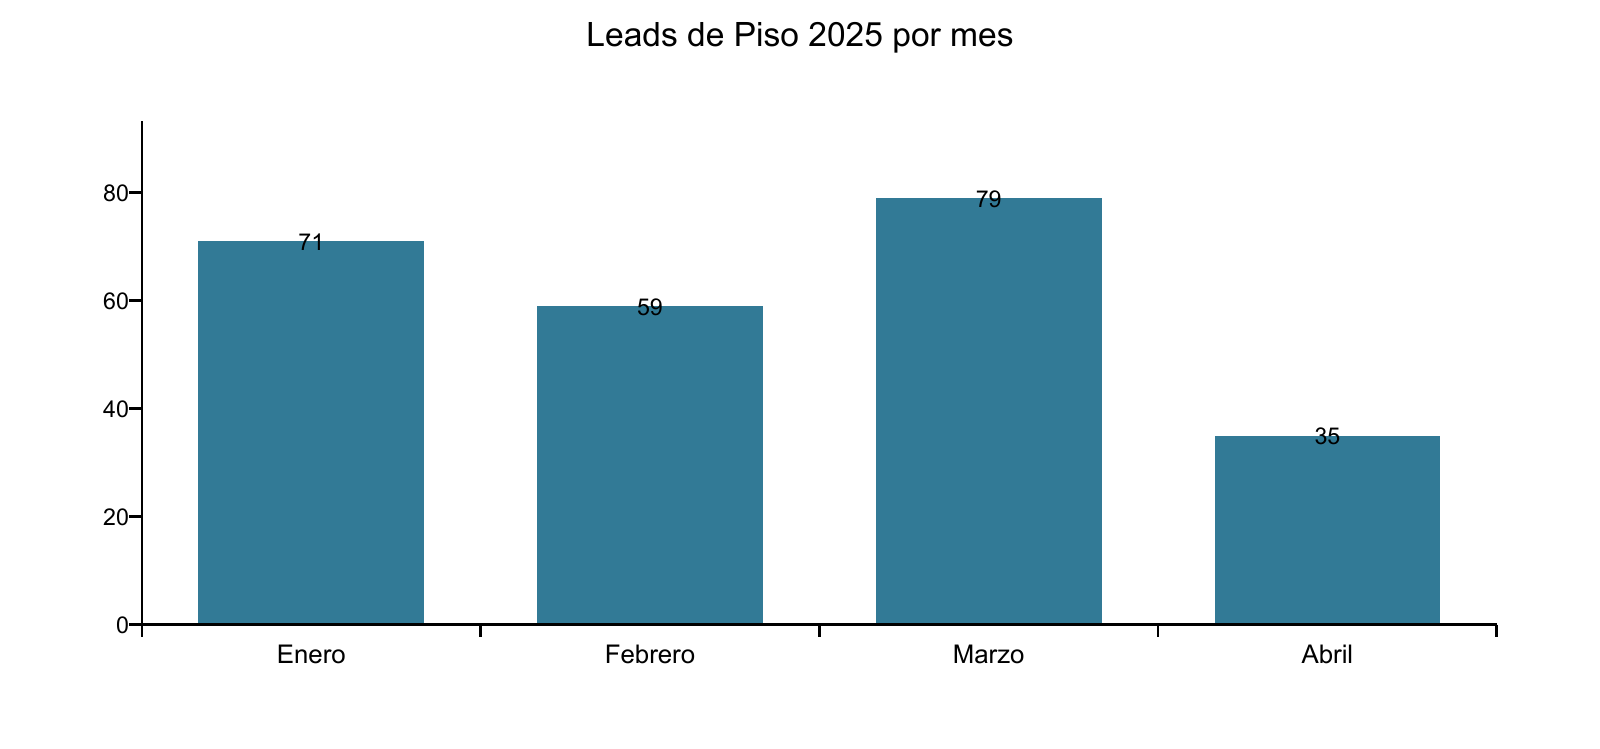

In [ ]:
# Totales mensuales después de separar cuentas administrativas
totales_mensuales = leads[meses].sum()
totales_mensuales.plot(kind="bar", color="#4C72B0")
plt.title("Totales mensuales de leads")
plt.xlabel("Mes")
plt.ylabel("Leads")
plt.show()

Figura 1. Totales mensuales después de separar cuentas administrativas.

Marzo tiene el mayor volumen, con 79 registros (32.38% del total). Abril tiene el menor, con 35 (14.34%). Entre marzo y abril se observa una reducción de 44 registros, equivalente al 55.70%; el archivo no permite establecer si se debe a actividad comercial o diferencias en captura.

| Asesor | Total de leads | Participación |
|---|---|---|
| ALAN GONZALES | 51 | 20.90% |
| PEDRO GONZALES | 44 | 18.03% |
| AURELIO FELIPE | 26 | 10.66% |
| MAURICIO ALFREDO | 22 | 9.02% |
| CARLOS ALBERTO NIETO | 20 | 8.20% |

Alan y Pedro suman 95 registros, el 38.93% del total. Quince asesores tienen al menos un registro. La media es 6.97 por asesor en el periodo y la mediana es cero, lo que refleja la concentración y la presencia de numerosos ceros.

## Agrupación mediante Sturges

Para los 35 totales por asesor, k = 1 + 3.32·log10(35) = 6.1263, redondeado a seis clases. El rango es 51 y la amplitud final es 8.5. Se usan intervalos cerrados a la derecha, incluyendo cero en la primera clase.

| [0, 8.5] | (8.5, 17] | (17, 25.5] | (25.5, 34] | (34, 42.5] | (42.5, 51] |
|---|---|---|---|---|---|
| 26 | 4 | 2 | 1 | 0 | 2 |

La fila numérica muestra la frecuencia de asesores. El paréntesis excluye el límite inferior y el corchete incluye el límite superior. La primera clase contiene los 20 asesores con cero registros.

# **EXTRACCIÓN DE CARACTERÍSTICAS DE BCS**

## Cumplimiento de metas por modelo

In [ ]:
bcs["Brecha"] = bcs["Ventas_Reales"] - bcs["Objetivo"]
bcs["Cumplimiento"] = bcs["Ventas_Reales"] / bcs["Objetivo"] * 100
bcs["Participacion"] = (
    bcs["Ventas_Reales"] / bcs["Ventas_Reales"].sum() * 100
)

| Modelo | Objetivo | Ventas | Brecha | Cumplimiento |
|---|---|---|---|---|
| EMZOOM | 22 | 14 | -8 | 63.64% |
| AION | 2 | 5 | +3 | 250.00% |
| EMKOO | 7 | 14 | +7 | 200.00% |
| GS4 | 3 | 5 | +2 | 166.67% |
| GN8 | 1 | 0 | -1 | 0.00% |
| GS8 | 9 | 3 | -6 | 33.33% |

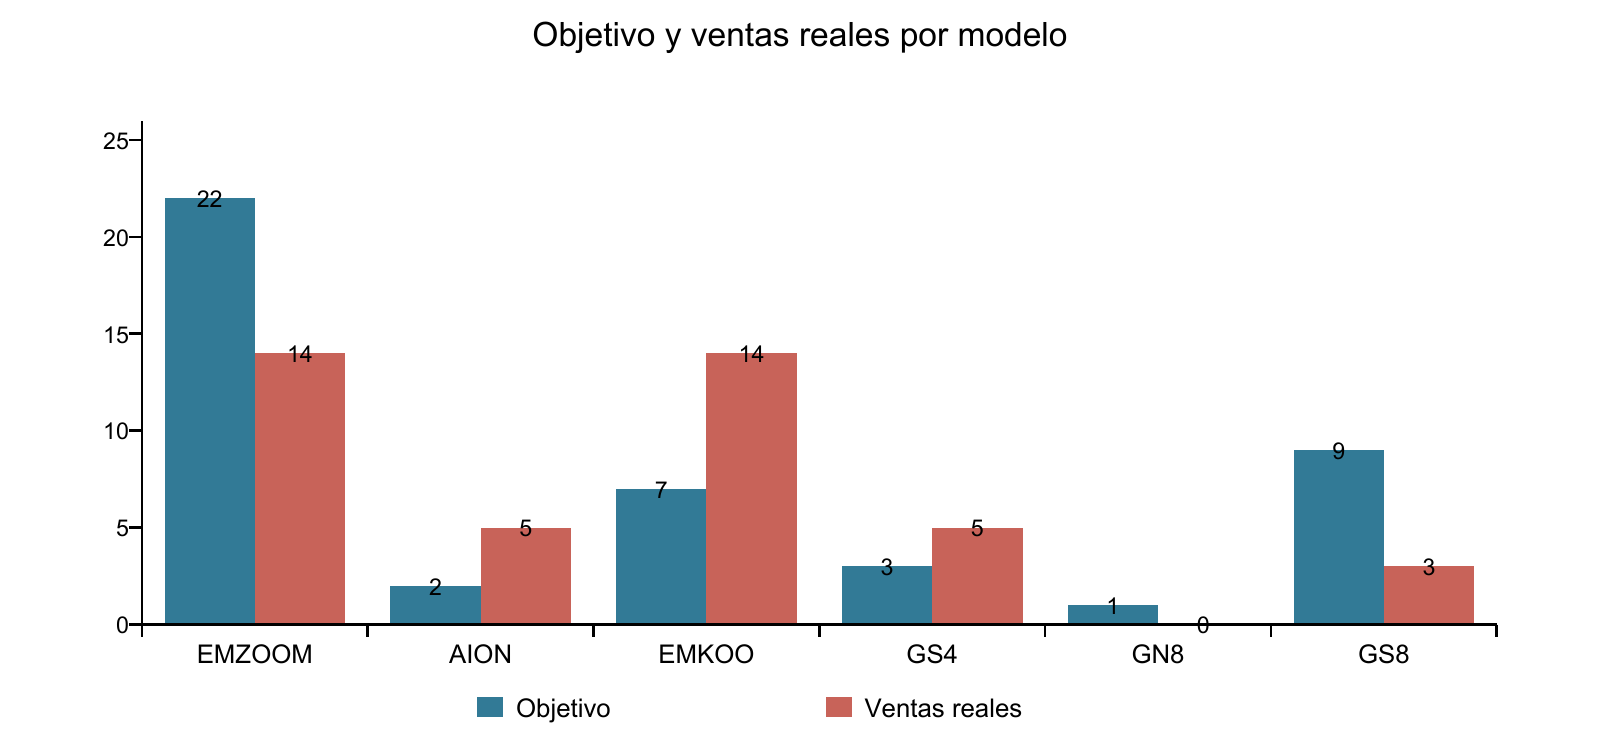

In [ ]:
# Comparación entre metas por modelo y ventas reales
ancho = 0.35
posiciones = np.arange(len(bcs))
plt.bar(posiciones - ancho / 2, bcs["Objetivo"], width=ancho, label="Objetivo")
plt.bar(posiciones + ancho / 2, bcs["Ventas_Reales"], width=ancho, label="Ventas reales")
plt.xticks(posiciones, bcs["Modelo"])
plt.title("Objetivo vs. ventas reales por modelo")
plt.legend()
plt.show()

Figura 2. Comparación entre las metas por modelo y sus ventas reales.

AION, EMKOO y GS4 superan sus metas; EMZOOM, GN8 y GS8 quedan por debajo. EMKOO presenta la mayor brecha positiva, con siete ventas sobre el objetivo, y EMZOOM la mayor brecha negativa, con ocho ventas por debajo.

EMZOOM y EMKOO registran 14 ventas cada uno. Juntos representan 28 de 41 ventas, equivalentes al 68.29%. Sin embargo, su cumplimiento difiere: 63.64% y 200%, respectivamente, debido a que las metas asignadas son distintas.

Un porcentaje alto con una meta pequeña no implica necesariamente el mayor volumen. AION alcanza 250% con cinco ventas, mientras que EMZOOM registra 14 ventas y no alcanza su meta. Por eso reviso simultáneamente unidades, brecha y cumplimiento.

# **REGRESIÓN LINEAL SIMPLE DE LEADS DE PISO**

## Relación entre mes y registros de leads

Sumo los cuatro meses entre los 35 asesores y codifico enero = 1, febrero = 2, marzo = 3 y abril = 4. El modelo utiliza cuatro observaciones mensuales. La variable independiente es Mes y la dependiente es Leads; no se modelan ventas porque esa variable no forma parte de esta base.

In [ ]:
mensual = pd.DataFrame({
    "Mes": [1, 2, 3, 4],
    "Leads": leads[meses].sum().to_numpy()
})
modelo_leads = LinearRegression().fit(mensual[["Mes"]], mensual["Leads"])
mensual["Prediccion"] = modelo_leads.predict(mensual[["Mes"]])
mensual["Residuo"] = mensual["Leads"] - mensual["Prediccion"]
r2 = modelo_leads.score(mensual[["Mes"]], mensual["Leads"])
r = mensual["Mes"].corr(mensual["Leads"])

Leads estimados = 83.0000 − 8.8000 × Mes

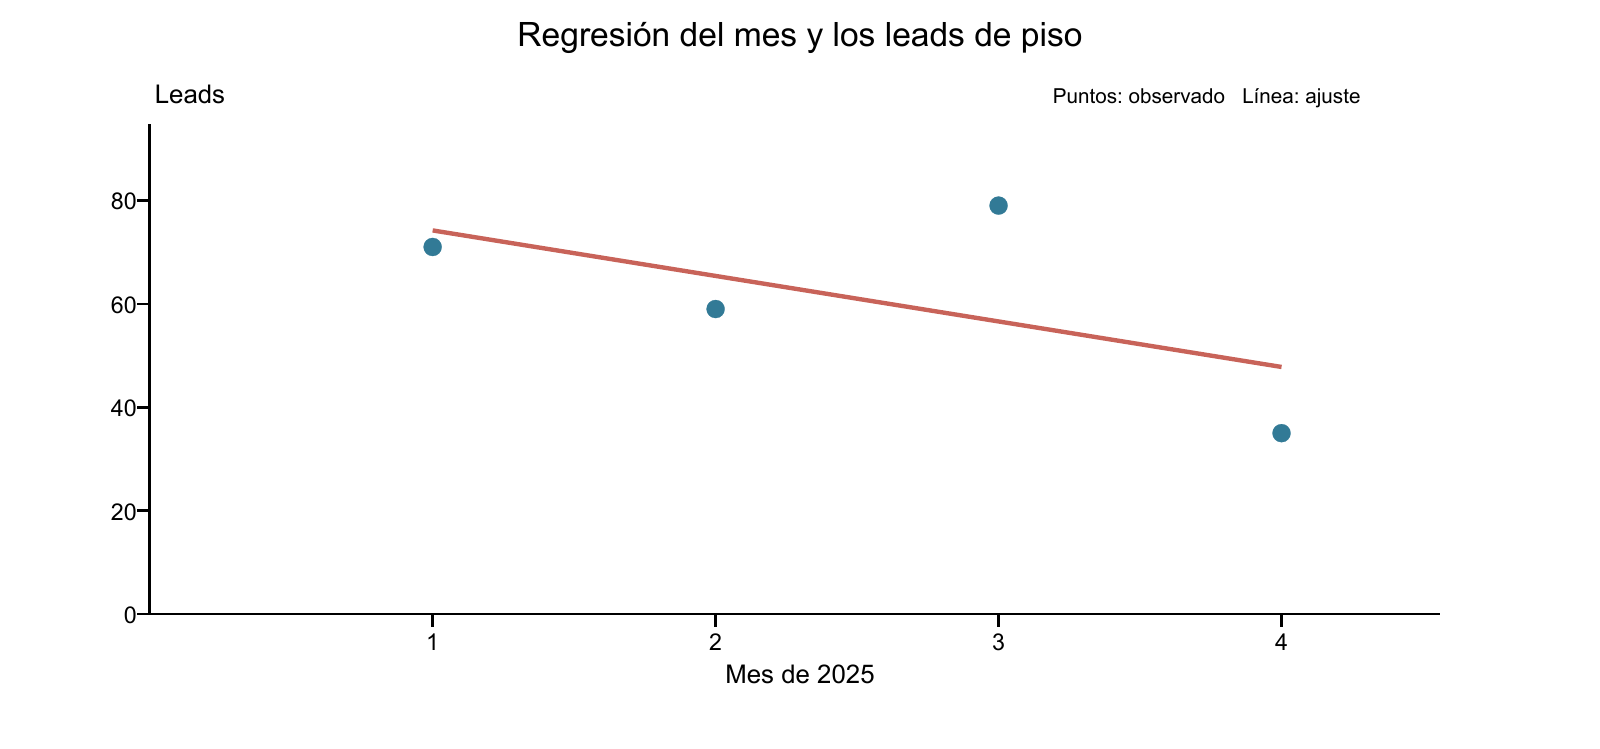

In [ ]:
plt.scatter(mensual["Mes"], mensual["Leads"], color="#4C72B0", label="Observado")
plt.plot(mensual["Mes"], mensual["Prediccion"], color="#DD8452", label="Predicción")
plt.title("Regresión de leads sobre el mes")
plt.xlabel("Mes")
plt.ylabel("Leads")
plt.legend()
plt.show()

Figura 3. Ajuste descriptivo de enero a abril de 2025.

| Mes | Leads | Predicción | Residuo |
|---|---|---|---|
| Enero | 71 | 74.2 | -3.2 |
| Febrero | 59 | 65.4 | -6.4 |
| Marzo | 79 | 56.6 | +22.4 |
| Abril | 35 | 47.8 | -12.8 |

R² = 0.3507 y r = -0.5922. La recta explica el 35.07% de la variación de estos cuatro totales. Su pendiente es negativa, pero marzo aumenta respecto de febrero; no existe una disminución uniforme.

La muestra de cuatro meses es insuficiente para una previsión anual sólida. El ajuste se evalúa con los mismos datos empleados para estimarlo y no demuestra que el paso del tiempo cause la reducción de registros.

# **REGRESIÓN LINEAL SIMPLE DE BCS**

## Relación entre objetivo y ventas reales

Defino Objetivo como variable independiente y Ventas_Reales como variable dependiente. Cada observación es uno de los seis modelos de vehículo. Este ajuste reproduce la relación trabajada en la actividad 5.2, sin reutilizar variables del modelo de leads.

In [ ]:
X_bcs = bcs[["Objetivo"]]
y_bcs = bcs["Ventas_Reales"]
modelo_bcs = LinearRegression().fit(X_bcs, y_bcs)
bcs["Prediccion"] = modelo_bcs.predict(X_bcs)
bcs["Residuo"] = bcs["Ventas_Reales"] - bcs["Prediccion"]
r2_bcs = modelo_bcs.score(X_bcs, y_bcs)
r_bcs = bcs["Objetivo"].corr(bcs["Ventas_Reales"])

Ventas reales estimadas = 3.0546 + 0.515284 × Objetivo

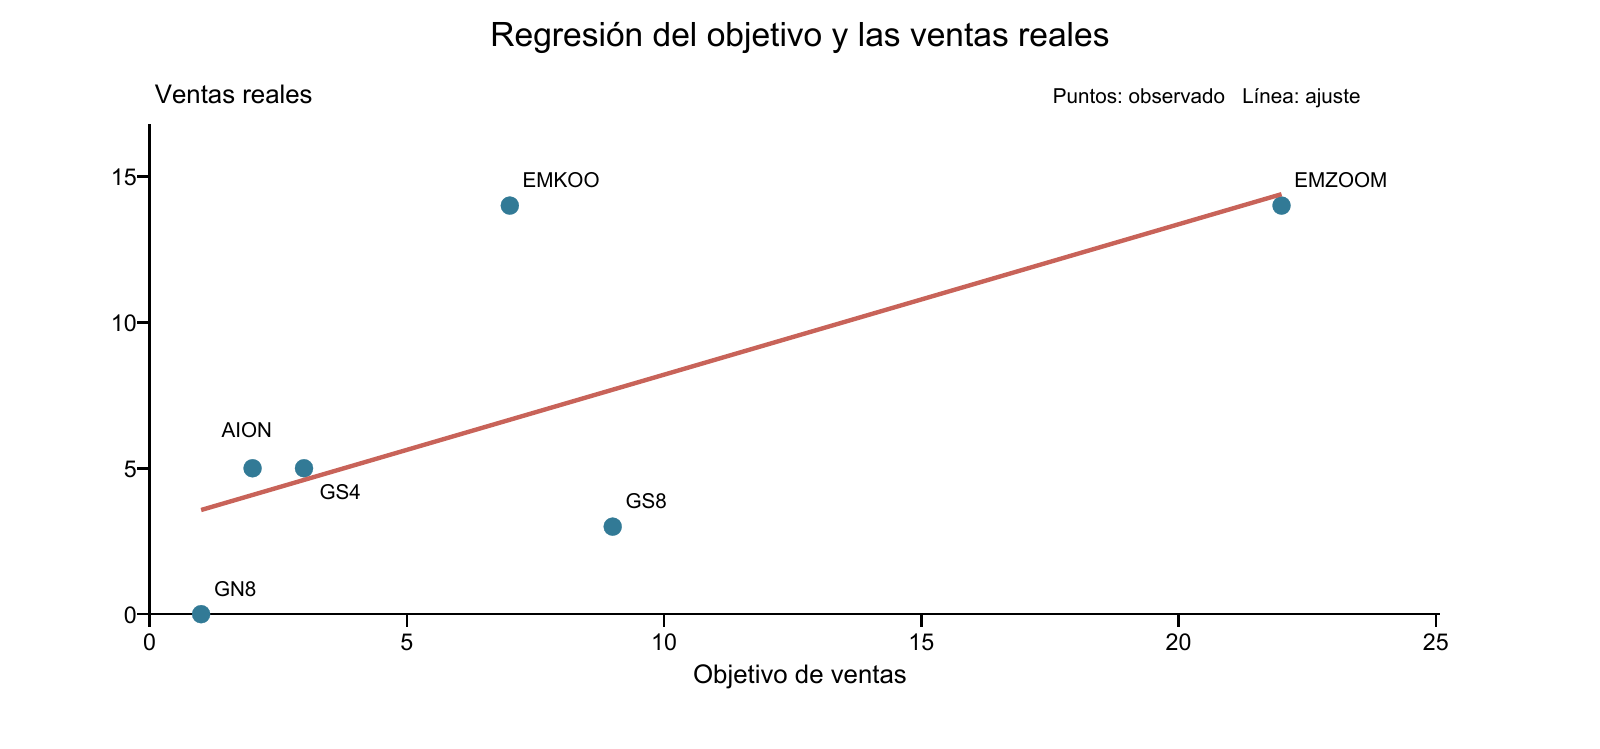

In [ ]:
plt.scatter(bcs["Objetivo"], bcs["Ventas_Reales"], color="#4C72B0", label="Observado")
plt.plot(bcs["Objetivo"], bcs["Prediccion"], color="#DD8452", label="Predicción")
plt.title("Regresión de ventas reales sobre el objetivo")
plt.xlabel("Objetivo")
plt.ylabel("Ventas reales")
plt.legend()
plt.show()

Figura 4. Regresión entre metas y ventas reales de los seis modelos.

| Modelo | Ventas reales | Predicción | Residuo |
|---|---|---|---|
| EMZOOM | 14 | 14.39 | -0.39 |
| AION | 5 | 4.09 | +0.91 |
| EMKOO | 14 | 6.66 | +7.34 |
| GS4 | 5 | 4.60 | +0.40 |
| GN8 | 0 | 3.57 | -3.57 |
| GS8 | 3 | 7.69 | -4.69 |

R² = 0.4746 y r = 0.6889. El modelo explica el 47.46% de la variación observada entre los seis modelos. La relación es positiva, aunque EMKOO vende bastante más de lo que indica la recta y GS8 menos.

La pendiente describe una asociación de aproximadamente 0.515 ventas por unidad adicional de objetivo. No significa que elevar una meta provoque ventas: los objetivos pueden haberse fijado según expectativas previas de demanda. El modelo es descriptivo y no tiene validación fuera de muestra.

# **ANÁLISIS DE CORRELACIÓN**

## Correlaciones entre variables originales

Calculo Pearson directamente, conservando su signo. Excluyo Total, Predicción, Brecha y Cumplimiento del mapa de variables originales para evitar interpretar relaciones que provienen de sumas o fórmulas.

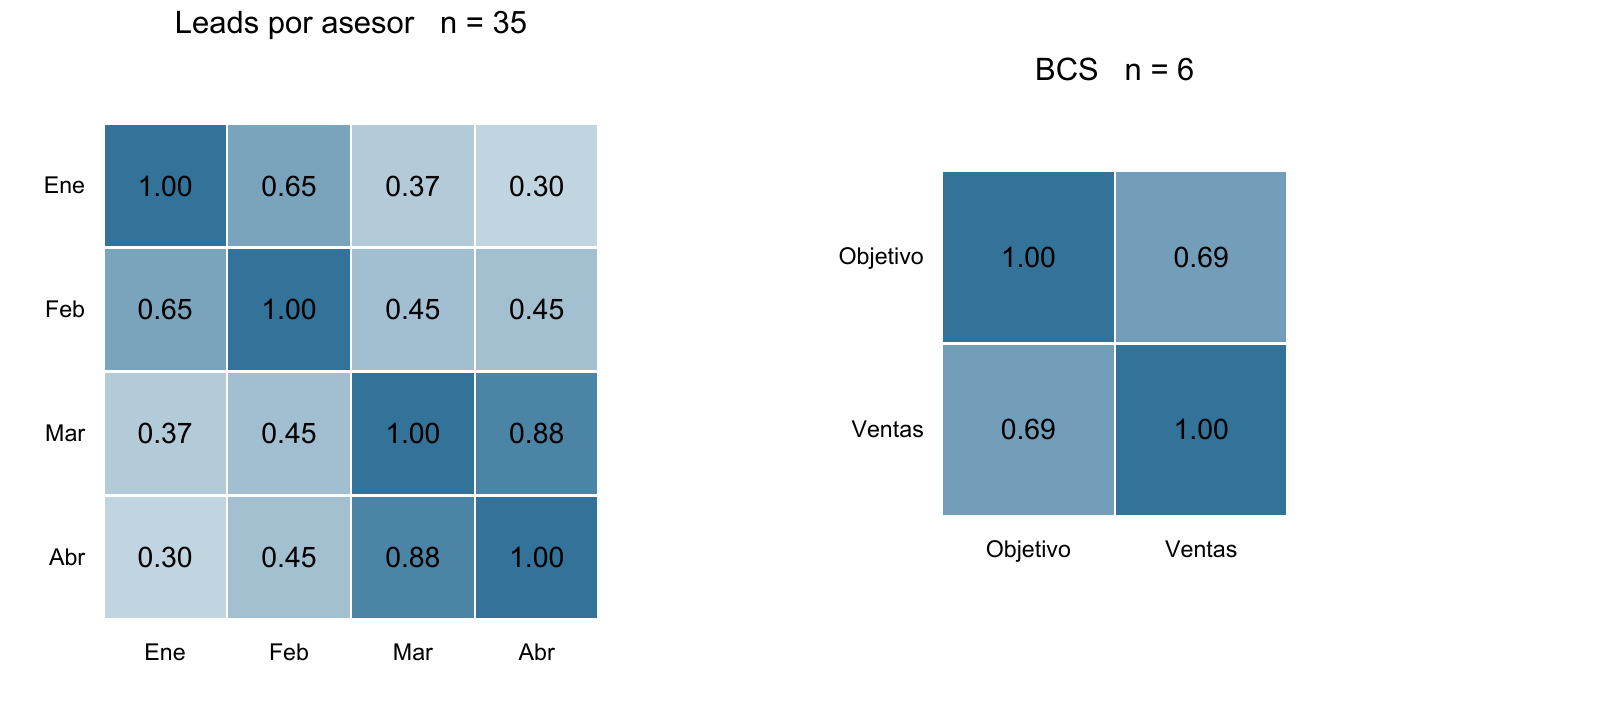

In [ ]:
corr_leads = leads[meses].corr()
corr_bcs = bcs[["Objetivo", "Ventas_Reales"]].corr()
sns.heatmap(corr_leads, annot=True, vmin=-1, vmax=1,
            cmap="coolwarm", fmt=".2f")
plt.show()
sns.heatmap(corr_bcs, annot=True, vmin=-1, vmax=1,
            cmap="coolwarm", fmt=".2f")
plt.show()

Figura 5. Correlaciones de los conteos por asesor y de los objetivos y ventas por modelo.

| Relación | Pearson r | Observaciones |
|---|---|---|
| Enero y febrero de leads | 0.6543 | 35 asesores |
| Marzo y abril de leads | 0.8793 | 35 asesores |
| Mes y total mensual de leads | −0.5922 | 4 meses |
| Objetivo y ventas reales BCS | 0.6889 | 6 modelos |

La correlación entre marzo y abril indica que los asesores con más registros en marzo tienden a registrar más en abril. No contradice la caída del total de abril: una relación entre asesores puede ser positiva aunque el volumen mensual disminuya.

Los numerosos asesores con cero en ambos meses influyen en estas relaciones. La matriz mensual por asesor usa 35 filas, mientras que la regresión temporal usa cuatro totales. Son unidades de análisis diferentes y sus coeficientes no deben compararse como si representaran lo mismo.

# **HALLAZGOS CLAVE DEL ANÁLISIS**

## Leads de Piso 2025

1. La base registra 244 leads entre enero y abril después de separar las cuentas administrativas. Marzo concentra 79 registros y abril 35. Esta variación requiere revisar la cobertura de captura antes de atribuirla a cambios en la demanda.

2. Alan Gonzales y Pedro Gonzales reúnen 95 registros, el 38.93% del total. Esta concentración describe el volumen registrado; no permite concluir quién convierte más leads en ventas o atiende con mayor calidad.

3. Veinte asesores tienen cero registros en todo el periodo. Conviene distinguir a quienes estaban activos de quienes todavía no ingresaban, ya no trabajaban en la agencia o no registraron su actividad.

4. Los cuatro totales más altos por asesor se detectan como atípicos mediante IQR y se conservan. Eliminarlos distorsionaría el volumen registrado sin una razón verificable de error.

## BCS

5. Los seis modelos suman 41 ventas reales. EMZOOM y EMKOO aportan 14 cada uno y concentran 68.29% de las ventas de esta sección.

6. EMKOO supera su meta en siete unidades y EMZOOM queda ocho por debajo. AION tiene el mayor cumplimiento porcentual, con 250%, pero su volumen es de cinco ventas. Las decisiones deben considerar ambos indicadores.

7. La suma de objetivos por modelo es 44, frente al objetivo general de 40 en el tablero. El cumplimiento de la sección cambia de 93.18% a 102.50% según el denominador; se necesita una definición única del indicador.

## Regresiones

8. La regresión de leads sobre Mes obtiene R² = 0.3507 y la de ventas de BCS sobre Objetivo obtiene R² = 0.4746. Ambas describen sus muestras, pero cuatro meses y seis modelos ofrecen evidencia limitada para predecir resultados futuros.

9. Las bases cubren unidades y referencias temporales diferentes. No permiten calcular una tasa común de conversión de leads de piso a ventas de BCS ni demostrar que los asesores con más leads expliquen las ventas de esos modelos.

## Conclusión

El análisis de Leads de Piso 2025 muestra concentración de registros entre pocos asesores y una reducción importante en abril. BCS muestra diferencias entre las metas y los resultados por modelo, además de una discrepancia entre el objetivo general y el desglosado. La prioridad es mejorar la consistencia de captura y las definiciones de los indicadores antes de convertir las relaciones estadísticas en decisiones comerciales.

La extracción, validación de nulos, revisión de atípicos, creación de características y regresión lineal permiten describir ambas bases de forma ordenada. Los resultados se mantienen separados para respetar sus periodos y unidades de observación.

# **FUENTES Y CÓDIGO DE APOYO**

## Bases principales

Leads de Piso 2025. Archivo leads_piso_2025_sin_nulos.csv, conservado en Actividad 2.2. Columnas utilizadas: Asesor, ene, feb, mar y abr. Los cálculos de esta evidencia parten de ese archivo ya procesado.

BCS. Archivo Analisis GAC Full7agosto 2026( BCS).csv, conservado en Actividad 5.2. Columnas seleccionadas por posición: 1, 3 y 4; filas correspondientes a los seis modelos de vehículo. El notebook Tarea 5.2.ipynb respalda la selección y regresión de BCS.

## Ejemplos complementarios

Citas Digitales. Tarea_valores_nulos.ipynb, actividad 2.1, respalda el ejemplo de sustitución de nulos. tarea_VA.ipynb, actividad 3.1, respalda el cálculo de IQR y la sustitución por mediana. Estos ejemplos no aportan observaciones a las regresiones principales.

## Frecuencias y categorías de leads

In [ ]:
frecuencia = leads[["Asesor", "Total"]].sort_values(
    "Total", ascending=False)
frecuencia["Porcentaje"] = (
    frecuencia["Total"] / frecuencia["Total"].sum() * 100)

k = round(1 + 3.32 * np.log10(len(leads)))
limites = np.linspace(leads["Total"].min(), leads["Total"].max(), k + 1)
leads["Categoria_Total"] = pd.cut(
    leads["Total"], bins=limites, include_lowest=True)
tabla_clases = leads["Categoria_Total"].value_counts(sort=False)

## Exportación de resultados

In [ ]:
leads.to_csv("Leads_Piso_2025_Evidencia.csv", index=False)
bcs.to_csv("BCS_Evidencia.csv", index=False)
mensual.to_csv("Regresion_Leads_Piso_2025.csv", index=False)

Los fragmentos de las secciones principales utilizan pandas, NumPy, matplotlib, seaborn y scikit-learn. Deben ejecutarse con las bases en el directorio de trabajo. El ejemplo de Citas Digitales es independiente y requiere cargar su base antes de usar la variable citas.

Las gráficas y estadísticas principales se calcularon a partir de los archivos indicados. Las predicciones se evalúan dentro de la muestra y no constituyen una prueba de desempeño con datos nuevos.

Los repositorios con los códigos correspondientes a cada fase: 
1. Extracción y transformación de datos
https://github.com/Carmen-fs/extraccion-de-datos.git
2. Limpieza de valores nulos.
https://github.com/Carmen-fs/Valores-Nulos.git 
3. Análisis de valores atípicos.
https://github.com/Carmen-fs/Valores-atipicos-.git 
4. Extracción de características y gráficas.
https://github.com/Carmen-fs/extraccion-de-caracteristicas.git 
5. Regresión lineal simple.
https://github.com/Carmen-fs/Regresion-lineal-simple.git 